# 🎓 Smart Attendance System using Face Recognition
### Pretrained FaceNet512 + SVM Classifier

**Workflow:**
1. Install dependencies
2. Organize dataset
3. Generate face embeddings using FaceNet512 (pretrained)
4. Train SVM classifier on embeddings
5. Evaluate model
6. Run recognition & log attendance
7. Export attendance CSV

## 📦 Step 1: Install Dependencies

In [52]:
!pip install deepface opencv-python-headless scikit-learn matplotlib seaborn tf-keras -q

## 📁 Step 2: Dataset Setup

Upload your images and organize them like this:
```
dataset/
├── Alice/
│   ├── photo1.jpg
│   └── photo2.jpg
├── Bob/
│   └── photo1.jpg
```
Each **folder name = person's name**. At least 1 image per person (3–5 recommended).

In [53]:
import os

DATASET_DIR = "/kaggle/input/datasets/anassbouch/dataset"

people = []
person_image_map = {}

for person_name in os.listdir(DATASET_DIR):
    person_path = os.path.join(DATASET_DIR, person_name)
    if not os.path.isdir(person_path):
        continue

    # Find the first subfolder (CV project / Mathias / im)
    subfolders = [f for f in os.listdir(person_path) if os.path.isdir(os.path.join(person_path, f))]
    img_folder = os.path.join(person_path, subfolders[0]) if subfolders else person_path

    people.append(person_name)
    person_image_map[person_name] = img_folder

print(f"✅ Found {len(people)} people: {people}")
for name, folder in person_image_map.items():
    imgs = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    print(f"  📷 {name}: {len(imgs)} image(s) → {folder}")

✅ Found 3 people: ['Anas', 'Mathias', 'Taha']
  📷 Anas: 50 image(s) → /kaggle/input/datasets/anassbouch/dataset/Anas/CV project
  📷 Mathias: 20 image(s) → /kaggle/input/datasets/anassbouch/dataset/Mathias/Mathias
  📷 Taha: 48 image(s) → /kaggle/input/datasets/anassbouch/dataset/Taha/im


## 👁️ Step 3: Preview Dataset Images

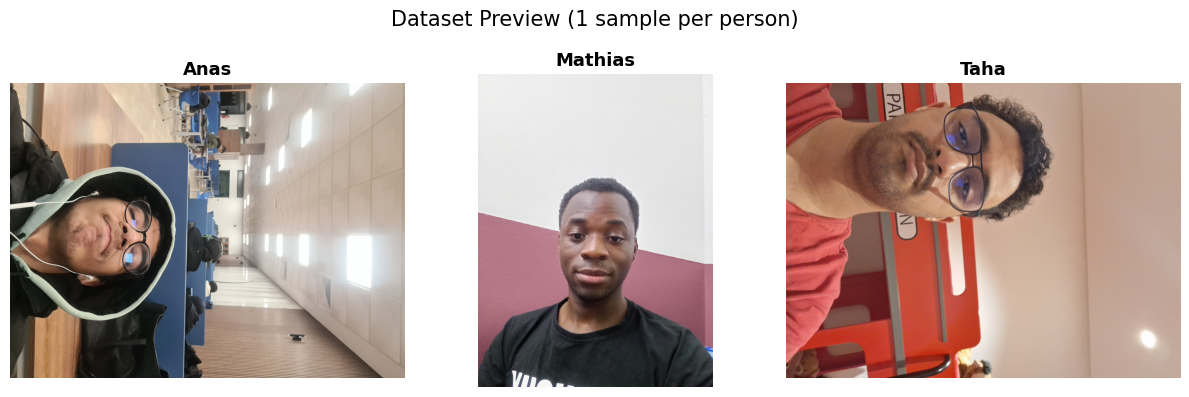

In [54]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, len(people), figsize=(4 * len(people), 4))
if len(people) == 1:
    axes = [axes]

for ax, person in zip(axes, people):
    folder = person_image_map[person]
    img_files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    img = mpimg.imread(os.path.join(folder, img_files[0]))
    ax.imshow(img)
    ax.set_title(person, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Dataset Preview (1 sample per person)', fontsize=15)
plt.tight_layout()
plt.show()

## 🧠 Step 4: Generate Face Embeddings (Pretrained ArcFace)

We use DeepFace to extract a 512-dimension vector per face.
The FaceNet512 model is **pretrained** — we don't retrain it, we just extract features.

In [55]:
from deepface import DeepFace
import os

# Test on one image and print the raw result
test_person = "Anas"
test_folder = person_image_map[test_person]
test_img = os.path.join(test_folder, os.listdir(test_folder)[0])

print(f"Testing: {test_img}")

try:
    result = DeepFace.represent(
        img_path=test_img,
        model_name=MODEL_NAME,
        detector_backend=DETECTOR,
        enforce_detection=False
    )
    print(f"Result type: {type(result)}")
    print(f"Result length: {len(result)}")
    print(f"Keys: {result[0].keys() if result else 'EMPTY LIST'}")
except Exception as e:
    print(f"Exception: {e}")

Testing: /kaggle/input/datasets/anassbouch/dataset/Anas/CV project/20251226_203226.jpg
Result type: <class 'list'>
Result length: 1
Keys: dict_keys(['embedding', 'facial_area', 'face_confidence'])


In [56]:
# Check the actual structure
if result and len(result) > 0:
    print(f"First item keys: {result[0].keys()}")
    for k, v in result[0].items():
        print(f"  {k}: type={type(v)}, value_preview={str(v)[:80]}")

First item keys: dict_keys(['embedding', 'facial_area', 'face_confidence'])
  embedding: type=<class 'list'>, value_preview=[-0.19734598696231842, 0.5509665608406067, -0.11018382757902145, -0.465663820505
  facial_area: type=<class 'dict'>, value_preview={'x': 1175, 'y': 2219, 'w': 540, 'h': 540, 'left_eye': None, 'right_eye': None}
  face_confidence: type=<class 'float'>, value_preview=0.96


In [57]:
from deepface import DeepFace
import numpy as np, json, os

# Force ArcFace explicitly
MODEL_NAME = "ArcFace"
DETECTOR = "opencv"

embeddings_db = {"Anas": [], "Mathias": [], "Taha": []}

for person in people:
    folder = person_image_map[person]
    img_files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    print(f"\n🔄 Processing {person} ({len(img_files)} images)...")

    for img_file in img_files:
        img_path = os.path.join(folder, img_file)
        try:
            result = DeepFace.represent(
                img_path=img_path,
                model_name="ArcFace",
                detector_backend="opencv",
                enforce_detection=False
            )
            emb = result[0]["embedding"]
            if isinstance(emb, list) and len(emb) > 0:
                embeddings_db[person].append(emb)
                print(f"  ✅ {img_file} → {len(emb)}d embedding")
            else:
                print(f"  ⚠️  {img_file} → empty embedding")
        except Exception as e:
            print(f"  ❌ {img_file} → {e}")

    print(f"  → {person} total: {len(embeddings_db[person])} embeddings")

# Save
with open("embeddings.json", "w") as f:
    json.dump(embeddings_db, f)

print("\n💾 Saved. Summary:")
for p, embs in embeddings_db.items():
    print(f"  {p}: {len(embs)}")


🔄 Processing Anas (50 images)...
  ✅ 20251226_203226.jpg → 512d embedding
  ✅ 20260222_223605.jpg → 512d embedding
  ✅ 20250820_195017.jpg → 512d embedding


Invalid SOS parameters for sequential JPEG


  ✅ IMG-20250802-WA0000.jpeg → 512d embedding


Invalid SOS parameters for sequential JPEG


  ✅ IMG-20251223-WA0026.jpeg → 512d embedding


...

  ✅ IMG-20250731-WA0032.jpeg → 512d embedding


Invalid SOS parameters for sequential JPEG


  ✅ IMG-20251223-WA0030.jpeg → 512d embedding
  ✅ 20260222_223619.jpg → 512d embedding


Invalid SOS parameters for sequential JPEG


  ✅ IMG-20250910-WA0015.jpeg → 512d embedding
  → Anas total: 50 embeddings

🔄 Processing Mathias (20 images)...
  ✅ IMG_20260421_221741_589.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_222101_144.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_222353_896.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_221849_041.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_221637_060.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_221935_177.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_222300_785.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_222347_814.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_221642_281.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_222246_503.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_222250_179.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_221834_650.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_221852_694.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_221805_250.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_222242_820.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_222351_795.jpg.jpeg → 512d embedding
  ✅ IMG_20260421_221808

## 🏋️ Step 5: Train SVM Classifier on Embeddings

We train a **Support Vector Machine (SVM)** on top of the frozen FaceNet embeddings.
This is the actual "training" step — fast and works great with small datasets.

In [58]:
import json, numpy as np

# Reload embeddings from file
with open("embeddings.json", "r") as f:
    embeddings_db = json.load(f)

X, y = [], []
for person, embs in embeddings_db.items():
    print(f"{person}: {len(embs)} embeddings")
    for emb in embs:
        if emb and len(emb) > 0:
            X.append(emb)
            y.append(person)

print(f"\nTotal: {len(X)} samples")
X = np.array(X)
print(f"Shape: {X.shape}")

Anas: 50 embeddings
Mathias: 20 embeddings
Taha: 48 embeddings

Total: 118 samples
Shape: (118, 512)


In [59]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, Normalizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pickle

# Build X (embeddings) and y (labels)
X, y = [], []
for person, embs in embeddings_db.items():
    for emb in embs:
        X.append(emb)
        y.append(person)

X = np.array(X)
print(f"📊 Dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(set(y))} classes")

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Pipeline: normalize embeddings → SVM
clf_pipeline = Pipeline([
    ("normalizer", Normalizer(norm="l2")),
    ("svm", SVC(kernel="linear", C=1.0, probability=True))
])

# If enough data, do train/test split; otherwise use all data
if X.shape[0] >= 4:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    clf_pipeline.fit(X_train, y_train)
    print(f"\n✅ Training accuracy : {clf_pipeline.score(X_train, y_train):.2%}")
    print(f"✅ Test accuracy      : {clf_pipeline.score(X_test, y_test):.2%}")
else:
    print("⚠️  Small dataset — training on all samples (no test split)")
    X_train, y_train = X, y_encoded
    X_test,  y_test  = X, y_encoded
    clf_pipeline.fit(X_train, y_train)
    print(f"✅ Training accuracy: {clf_pipeline.score(X_train, y_train):.2%}")

# Save model
pickle.dump(clf_pipeline, open("face_classifier.pkl", "wb"))
pickle.dump(le,           open("label_encoder.pkl",   "wb"))
print("\n💾 Saved face_classifier.pkl and label_encoder.pkl")

📊 Dataset: 118 samples, 512 features, 3 classes

✅ Training accuracy : 85.11%
✅ Test accuracy      : 83.33%

💾 Saved face_classifier.pkl and label_encoder.pkl


## 📈 Step 6: Evaluate — Confusion Matrix & Classification Report

📋 Classification Report:
              precision    recall  f1-score   support

        Anas       0.71      1.00      0.83        10
     Mathias       1.00      0.75      0.86         4
        Taha       1.00      0.70      0.82        10

    accuracy                           0.83        24
   macro avg       0.90      0.82      0.84        24
weighted avg       0.88      0.83      0.83        24



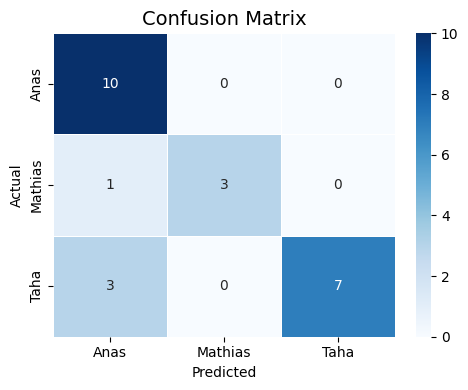

In [60]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = clf_pipeline.predict(X_test)
labels = le.inverse_transform(sorted(set(y_test)))

print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(max(5, len(labels)), max(4, len(labels))))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
            cmap="Blues", linewidths=0.5)
plt.title("Confusion Matrix", fontsize=14)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 🎯 Step 7: Recognition Function

Feed any photo → get name + confidence + attendance logged.

In [61]:
import pandas as pd
from datetime import datetime

CONFIDENCE_THRESHOLD = 0.55  # Tune this: lower = more lenient, higher = stricter
ATTENDANCE_FILE = "attendance.csv"

# Load or create attendance log
if os.path.exists(ATTENDANCE_FILE):
    attendance_df = pd.read_csv(ATTENDANCE_FILE)
else:
    attendance_df = pd.DataFrame(columns=["Name", "Date", "Time", "Confidence"])


def recognize_and_log(img_path, show_image=True):
    """Recognize a face and mark attendance. Returns name or None."""
    global attendance_df

    try:
        result = DeepFace.represent(
            img_path=img_path,
            model_name=MODEL_NAME,
            detector_backend=DETECTOR,
            enforce_detection=False
        )
        emb = np.array(result[0]["embedding"]).reshape(1, -1)
    except Exception as e:
        print(f"❌ Could not extract face: {e}")
        return None

    # Predict
    proba      = clf_pipeline.predict_proba(emb)[0]
    confidence = proba.max()
    pred_idx   = proba.argmax()
    name       = le.inverse_transform([pred_idx])[0]

    now  = datetime.now()
    date = now.strftime("%Y-%m-%d")
    time = now.strftime("%H:%M:%S")

    if confidence >= CONFIDENCE_THRESHOLD:
        # Prevent duplicate in same day
        already_logged = (
            (attendance_df["Name"] == name) & (attendance_df["Date"] == date)
        ).any()

        if not already_logged:
            new_row = {"Name": name, "Date": date, "Time": time, "Confidence": f"{confidence:.2%}"}
            attendance_df = pd.concat([attendance_df, pd.DataFrame([new_row])], ignore_index=True)
            attendance_df.to_csv(ATTENDANCE_FILE, index=False)
            status = f"✅ Attendance marked for {name} ({confidence:.2%})"
        else:
            status = f"ℹ️  {name} already marked today ({confidence:.2%})"
    else:
        name   = "Unknown"
        status = f"❓ Face not recognized (best guess: {le.inverse_transform([pred_idx])[0]} @ {confidence:.2%})"

    # Display
    if show_image:
        img = mpimg.imread(img_path)
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(status, fontsize=10, wrap=True)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(status)

    return name if name != "Unknown" else None


print("✅ recognize_and_log() is ready.")
print("Usage: recognize_and_log('path/to/test_image.jpg')")

✅ recognize_and_log() is ready.
Usage: recognize_and_log('path/to/test_image.jpg')


## 🧪 Step 8: Test with a New Image

⚠️  'test_image.jpg' not found.
Upload a test image and update the TEST_IMAGE path above.
👉 Running self-test with: /kaggle/input/datasets/anassbouch/dataset/Anas/CV project/20251226_203226.jpg


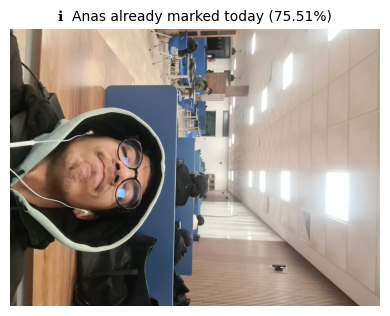

In [62]:
# ✏️ Change this path to any test image
TEST_IMAGE = "test_image.jpg"

if os.path.exists(TEST_IMAGE):
    recognize_and_log(TEST_IMAGE)
else:
    print(f"⚠️  '{TEST_IMAGE}' not found.")
    print("Upload a test image and update the TEST_IMAGE path above.")

    # Fallback: test with a dataset image
    sample_person = people[0]
    sample_folder = person_image_map[sample_person]  # use person_image_map, not DATASET_DIR
    sample_imgs = [f for f in os.listdir(sample_folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    sample_path = os.path.join(sample_folder, sample_imgs[0])
    
    print(f"👉 Running self-test with: {sample_path}")
    recognize_and_log(sample_path)


## 📊 Step 9: View Attendance Log

In [63]:
print("📋 Current Attendance Log:\n")

if attendance_df.empty:
    print("No attendance recorded yet.")
else:
    display(attendance_df.style.set_properties(**{'text-align': 'left'}))
    print(f"\n📌 Total records: {len(attendance_df)}")

    # Summary per person
    summary = attendance_df.groupby("Name").size().reset_index(name="Days Present")
    print("\n📊 Attendance Summary:")
    display(summary)

📋 Current Attendance Log:



,Name,Date,Time,Confidence
0,Anas,2026-04-23,12:30:32,75.63%



📌 Total records: 1

📊 Attendance Summary:


,Name,Days Present
0,Anas,1


## 💾 Step 10: Export Attendance

In [64]:
if not attendance_df.empty:
    export_path = f"attendance_export_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    attendance_df.to_csv(export_path, index=False)
    print(f"✅ Attendance exported to: {export_path}")
    
    # Also show as styled table
    print("\n📋 Final Attendance Sheet:")
    display(attendance_df)
else:
    print("⚠️ No attendance to export yet.")

✅ Attendance exported to: attendance_export_20260423_124732.csv

📋 Final Attendance Sheet:


,Name,Date,Time,Confidence
0,Anas,2026-04-23,12:30:32,75.63%


---
## ✅ Summary

| Step | What happened |
|------|---------------|
| ArcFace | Pretrained model extracted 512-dim face embeddings |
| SVM Classifier | Trained on your embeddings — fast, accurate on small datasets |
| Attendance log | Auto-saved to `attendance.csv`, deduplicated per day |
| Export | Final CSV ready to share |

**Tips:**
- Add more photos per person → higher accuracy
- Adjust `CONFIDENCE_THRESHOLD` (0.55 default) if getting wrong matches
- Switch `model_name` to `"ArcFace"` for better accuracy on diverse faces
- Switch `detector_backend` to `"retinaface"` for better face detection